# CSP Traffic — Control de Intersecciones con Problemas de Satisfacción de Restricciones
**Actividad Puntos Extra**

---
**Nombre:** Laurie Camila Hernández Pacheco
**Matrícula:** A01286569

---
## 1. Definición del Problema

Se realizó el modelado de un cruce semafórico que intersecciona dos calles distintas: una en posición vertical y la otra en posición horizontal. El flujo de vehículos tiene 4 posibles vías: 
- Norte a Sur
- Sur a Norte
- Oeste a Este
- Este a Oeste

Cada vehículo tiene como objetivo llegar a su destino final, y para ello pueden avanzar o detenerse. Este comportamiento se define con base en lo necesario para evitar colisiones y a la par que la mayor cantidad de vehículos logren cruzar a su destino. Para controlar esto, se implementarán 4 semáforos que instruyan a los vehículos si deben de avanzar o detenerse. 

El sistema asume que todos los vehículos manejan a velocidad constante, así como que las reglas siempre se cumplen (¡no se asumen conductores irrespetuosos!). 

### Variables del CSP

Se definen a continuación 4 variables, que representarán el estado de cada uno de los semáforos: 

| Variable | Descripción |
|----------|-------------|
| `L_N` | Semáforo Norte |
| `L_S` | Semáforo Sur |
| `L_E` | Semáforo Este |
| `L_W` | Semáforo Oeste |

Cada una de estas variables está definida de tal forma que puede tomar tres valores: $\{R, Y, G\}$, donde $R$ simboliza "rojo", $Y$ simboliza "amarillo" y "G" simboliza "verde". A este conjunto de valores se le conoce como el **dominio** de las variables. $R$ simboliza que el vehículo debe de detenerse completamente, mientras que $G$ simboliza que el vehículo puede avanzar. En el escenario de $Y$, los vehículos se mantienen avanzando si y solo sí ya cruzaron la línea de parada. 

### Restricciones

En un sistema CSP es necesario denominar ciertas restricciones, lo cual sirve para determinar las reglas que el sistema debe de satisfacer. Se proponen 5 restricciones estándar para el funcionamiento del cruce semafórico: 

1. **Compatibilidad Norte-Sur:** Pueden estar verdes simultáneamente (flujo paralelo). 
$$
L_N = G \iff L_S = G
$$
2. **Compatibilidad Este-Oeste:** Pueden estar verdes simultáneamente (flujo paralelo).
$$ 
L_E = G \iff L_W = G
$$
3. **Incompatibilidad de flujos cruzados:** Se cumple lo siguiente: 
$$ 
\neg\, (L_N = G \wedge L_S = G) \vee \neg\,(L_E = G \wedge L_W = G)
$$
4. **No pueden estar todas las luces en rojo simultáneamente:** No todos pueden estar en rojo al mismo tiempo, el sistema debe estar en flujo constante.
$$
\neg(L_N = R \wedge L_S = R \wedge L_E = R \wedge L_W = R)
$$
5. **Transición segura en amarillo:** Un par de semáforos solo puede estar en amarillo si el par perpendicular está completamente en rojo. Esto garantiza que la fase de desalojo no se solape con una fase activa del flujo contrario.
$$
(L_N = Y \vee L_S = Y) \implies (L_E = R \wedge L_W = R)
$$
$$
(L_E = Y \vee L_W = Y) \implies (L_N = R \wedge L_S = R)
$$

---
## 2. Implementación de CSP

El enfoque para la implementación del CSP fue mediante **backtracking recursivo**, donde el objetivo es resolver el problema probando distintas asignaciones a las variables y retrocediendo en caso de que alguna asignación no cumpla con las restricciones, llamando a la misma función en cada ocasión. 

Inicialmente, definimos las distintas librerías utilizadas y su explicación: 
- `itertools`: se utilizó para la generación de posibles combinaciones en las variables sobre los valores posibles del dominio. 
- `matplotlib`: es una librería estándar para la visualización de gráficas. Se utilizó principalmente para generar visualizaciones dentro del proyecto, tales como la simulación video final, una visualización de las posibles configuraciones del sistema, y gráficas de series de tiempo para visualizar el flujo de los vehículos. 
- `numpy`: esta librería permite el manejo de operaciones y arreglos dentro de la animación. Se generaron los rangos de las líneas de las calles y también se utiliza para establecer las posiciones tanto de los vehículos como de los puntos del cruce importantes. 
- `random`: esta librería se utilizó para modelar la aleatoriedad del sistema, permitiendo la llegada de vehículos, colores, y decisión probabilística de la aparición de los coches en la animación. 
- `math`: es una librería estándar que permitió en la simulación realizar la rotación de los vehículos. 
- `IPython`: para poder visualizar en la libreta la simulación directamente. 

In [8]:
from itertools import product
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import random
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import math
from IPython.display import HTML

### 2.1 Backtracking

Con las variables definidas y el dominio definido, se instanciaron sus respectivas listas. De ellas, se definieron dos funciones: 
- `is_valid`: Verifica que una asignación satisfaga con todas las restricciones del CSP. En este caso, utilizamos las restricciones ya predefinidas y se validan. 
- `backtrack`: Encuentra todas las asignaciones válidas usando backtracking recursivo. Este backtracking consiste en que el programa prueba una asignación de variables y se llama a si mismo para continuar. en caso de que falle en el proceso, regresa a su estado anterior y vuelve a probar pero con un valor distinto. 

In [9]:
# definimos las variables y dominio 
variables = ["L_N", "L_S", "L_E", "L_W"]
domain    = ["R", "Y", "G"]   

def is_valid(assignment: dict) -> bool:
    
    N = assignment.get("L_N", "R")
    S = assignment.get("L_S", "R")
    E = assignment.get("L_E", "R")
    W = assignment.get("L_W", "R")

    # restricción 1: N y S deben tener el mismo estado.
    if N != S:
        return False

    # restricción 2: E y W deben tener el mismo estado.
    if E != W:
        return False

    # restricción 3: flujos cruzados no pueden estar activos (G o Y) simultáneamente.
    ns_active = N in ("G", "Y")
    ew_active = E in ("G", "Y")
    if ns_active and ew_active:
        return False

    # restricción 4: al menos una dirección debe estar en verde.
    if all(v == "R" for v in [N, S, E, W]):
        return False

    # restricción 5: amarillo solo es válido cuando el par contrario esta en rojo.
    if N == "Y" and E != "R":
        return False
    if E == "Y" and N != "R":
        return False

    return True

def backtrack(assignment: dict, variables: list, domain: list) -> list:
    """Encuentra todas las asignaciones válidas usando backtracking recursivo."""
    solutions = []

    if len(assignment) == len(variables):
        if is_valid(assignment):
            solutions.append(dict(assignment))
        return solutions

    var = variables[len(assignment)]

    for value in domain:
        assignment[var] = value
        partial_valid = True
        N = assignment.get("L_N", None)
        S = assignment.get("L_S", None)
        E = assignment.get("L_E", None)
        W = assignment.get("L_W", None)

        # poda: N y S ya asignadas deben coincidir
        if N is not None and S is not None and N != S:
            partial_valid = False

        # poda: E y W ya asignadas deben coincidir
        if E is not None and W is not None and E != W:
            partial_valid = False

        # poda: flujos cruzados activos (G o Y)
        ns_active = any(v in ("G","Y") for v in [N, S] if v)
        ew_active = any(v in ("G","Y") for v in [E, W] if v)
        if ns_active and ew_active:
            partial_valid = False

        # poda: amarillo con contrario no-rojo
        if N == "Y" and E is not None and E != "R":
            partial_valid = False
        if E == "Y" and N is not None and N != "R":
            partial_valid = False

        if partial_valid:
            solutions += backtrack(assignment, variables, domain)

        del assignment[var]

    return solutions


# Ejecutar backtracking
all_solutions = backtrack({}, variables, domain)

# se muestran las configuraciones válidas
print(f"Configuraciones válidas encontradas: {len(all_solutions)}")
print()
print(f"{'N':>6} {'S':>6} {'E':>6} {'W':>6}   Descripción")
print("-" * 65)
for sol in all_solutions:
    desc = []
    if sol["L_N"] == "G":  desc.append("Flujo N-S activo (Verde)")
    if sol["L_N"] == "Y":  desc.append("Flujo N-S en transición (Amarillo)")
    if sol["L_E"] == "G":  desc.append("Flujo E-W activo (Verde)")
    if sol["L_E"] == "Y":  desc.append("Flujo E-W en transición (Amarillo)")
    label = " + ".join(desc)
    print(f"{sol['L_N']:>6} {sol['L_S']:>6} {sol['L_E']:>6} {sol['L_W']:>6}   {label}")


Configuraciones válidas encontradas: 4

     N      S      E      W   Descripción
-----------------------------------------------------------------
     R      R      Y      Y   Flujo E-W en transición (Amarillo)
     R      R      G      G   Flujo E-W activo (Verde)
     Y      Y      R      R   Flujo N-S en transición (Amarillo)
     G      G      R      R   Flujo N-S activo (Verde)


### 2.2 Visualización de posibles soluciones

Una vez definidas las 4 posibilidades del estado del cruce, se realizó una breve visualización utilizando un modelo del cruce. Esto es únicamente para visualizar las luces que pueden estar encendidas a lo largo de la simulación y las diferentes combinaciones. 

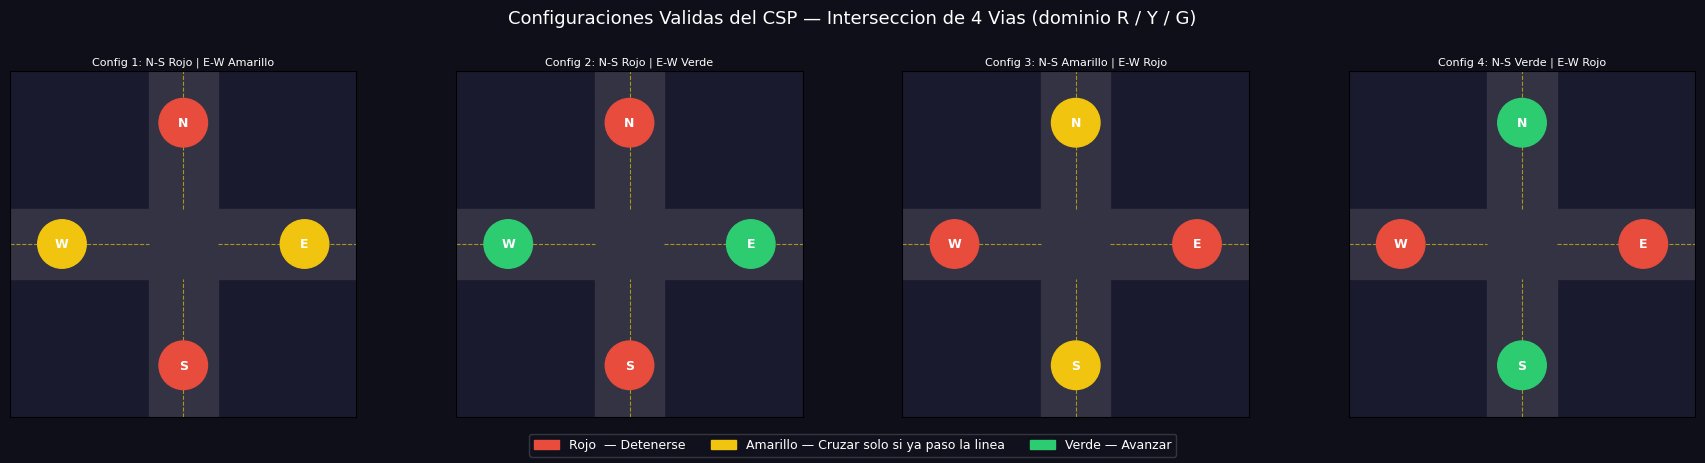

In [10]:
color_map = {"R": "#E74C3C", "Y": "#F1C40F", "G": "#2ECC71"}
dir_positions = {
    "L_N": (0.5, 0.85),
    "L_S": (0.5, 0.15),
    "L_E": (0.85, 0.5),
    "L_W": (0.15, 0.5),
}
dir_labels = {"L_N": "N", "L_S": "S", "L_E": "E", "L_W": "W"}

n_sols = len(all_solutions)
cols   = 4
rows   = (n_sols + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4.5))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, sol in enumerate(all_solutions):
    ax = axes[i]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_facecolor('#1a1a2e')
    ax.set_xticks([]); ax.set_yticks([])

    # Carreteras
    ax.add_patch(plt.Rectangle((0.4, 0), 0.2, 1, color='#333344'))
    ax.add_patch(plt.Rectangle((0, 0.4), 1, 0.2, color='#333344'))
    ax.plot([0.5, 0.5], [0, 0.4],  '--', color='#FFD700', lw=0.8, alpha=0.6)
    ax.plot([0.5, 0.5], [0.6, 1],  '--', color='#FFD700', lw=0.8, alpha=0.6)
    ax.plot([0, 0.4],   [0.5, 0.5],'--', color='#FFD700', lw=0.8, alpha=0.6)
    ax.plot([0.6, 1],   [0.5, 0.5],'--', color='#FFD700', lw=0.8, alpha=0.6)

    # Semáforos
    for var, (x, y) in dir_positions.items():
        color = color_map[sol[var]]
        circle = plt.Circle((x, y), 0.07, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, dir_labels[var], ha='center', va='center',
                fontsize=9, fontweight='bold', color='white', zorder=6)

    # Título
    state_ns = sol["L_N"]
    state_ew = sol["L_E"]
    desc_ns  = {"G": "N-S Verde", "Y": "N-S Amarillo", "R": "N-S Rojo"}
    desc_ew  = {"G": "E-W Verde", "Y": "E-W Amarillo", "R": "E-W Rojo"}
    ax.set_title(f"Config {i+1}: {desc_ns[state_ns]} | {desc_ew[state_ew]}",
                 fontsize=8, color='white', pad=4)

# Ocultar ejes sobrantes
for j in range(n_sols, len(axes)):
    axes[j].set_visible(False)

# Leyenda
red_patch    = patches.Patch(color='#E74C3C', label='Rojo  — Detenerse')
yellow_patch = patches.Patch(color='#F1C40F', label='Amarillo — Cruzar solo si ya paso la linea')
green_patch  = patches.Patch(color='#2ECC71', label='Verde — Avanzar')
fig.legend(handles=[red_patch, yellow_patch, green_patch], loc='lower center',
           ncol=3, fontsize=9, framealpha=0.2, labelcolor='white',
           facecolor='#1a1a2e')

fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Configuraciones Validas del CSP — Interseccion de 4 Vias (dominio R / Y / G)',
             fontsize=13, color='white', y=1.00)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig('csp_configuraciones.png', dpi=150, bbox_inches='tight')
plt.show()


Se determinó finalmente que para cumplir las 4 restricciones de manera óptima, este acomodo de ambas luces verticales o ambas luces horizontales de color verde o amarillo son los que permiten satisfacer las restricciones. 

## 3. Simulación del flujo vehicular (250 pasos)

Finalmente, se realizó la simulación del flujo vehicular siguiendo las restricciones que permite el modelo CSP. Inicialmente se definieron las posibles fases para el sistema, que es que ambas rutas N y S estén en color verde, o E y W que estén en color verde. Para esta sección, se definió la siguiente función:
- `simulate_traffic`: Simula el flujo vehicular en la intersección durante 250 pasos. 

In [11]:
# se definen únicamente dos fases funcionales para el flujo de vehículos (pues ambas luces color amarillo no indican "avance" per se)
PHASES = [
    {"L_N": "G", "L_S": "G", "L_E": "R", "L_W": "R"},  # Fase 1: N-S verde
    {"L_N": "R", "L_S": "R", "L_E": "G", "L_W": "G"},  # Fase 2: E-W verde
]

PHASE_DURATION  = 30   # pasos en verde
YELLOW_DURATION = 5    # pasos en amarillo de transicion
TOTAL_STEPS     = 250

# fraccion de autos que ya cruzaron la linea al arrancar el amarillo.
YELLOW_COMMIT_RATE = 0.4

def simulate_traffic(total_steps=250):
    """
    Simula el flujo vehicular en la interseccion durante 250 pasos
    """
    # se instancían las variables iniciales necesarias para la simulación
    log = []
    # contadores acumulados para las rutas
    cars_passed_ns = 0
    cars_passed_ew = 0

    cars_waiting_ns = random.randint(1, 5)
    cars_waiting_ew = random.randint(1, 5)

    current_phase  = 0
    step_in_phase  = 0
    in_yellow      = False

    last_green_ns_flow = 2
    last_green_ew_flow = 2

    # en casa paso, se agregan entre 0 y 2 carros de manera aleatoria a la simulación cada paso. 
    for step in range(1, total_steps + 1):
        cars_waiting_ns += random.randint(0, 2)
        cars_waiting_ew += random.randint(0, 2)

        # se determina el estado del semaforo
        if in_yellow:
            # si es amarillo, todos los semáforos lo son para simular la transición entre estados. 
            state_ns = "Y"
            state_ew = "Y"
            step_in_phase += 1
            if step_in_phase >= YELLOW_DURATION:
                current_phase = 1 - current_phase
                step_in_phase = 0
                in_yellow = False
        else:
            phase = PHASES[current_phase]
            state_ns = phase["L_N"]
            state_ew = phase["L_E"]
            step_in_phase += 1
            if step_in_phase >= PHASE_DURATION:
                in_yellow = True
                step_in_phase = 0

        passed_ns = 0
        passed_ew = 0

        if state_ns == "G":
            # si es verde de norte a sur o sur a norte 
            passed_ns = min(cars_waiting_ns, random.randint(1, 4))
            cars_waiting_ns = max(0, cars_waiting_ns - passed_ns)
            cars_passed_ns += passed_ns
            last_green_ns_flow = passed_ns

        elif state_ns == "Y":
            # solo los ya comprometidos (cruzaron la linea) siguen pasando
            committed = int(round(last_green_ns_flow * YELLOW_COMMIT_RATE))
            # limitamos a que no pasen más autos de los que realmente están esperando. 
            passed_ns = min(cars_waiting_ns, committed) 
            cars_waiting_ns = max(0, cars_waiting_ns - passed_ns)
            cars_passed_ns+= passed_ns

        if state_ew == "G":
            passed_ew = min(cars_waiting_ew, random.randint(1, 4))
            cars_waiting_ew = max(0, cars_waiting_ew - passed_ew)
            cars_passed_ew += passed_ew
            last_green_ew_flow = passed_ew

        elif state_ew == "Y":
            committed = int(round(last_green_ew_flow * YELLOW_COMMIT_RATE))
            passed_ew = min(cars_waiting_ew, committed)
            cars_waiting_ew = max(0, cars_waiting_ew - passed_ew)
            cars_passed_ew += passed_ew

        # es guarda el sistema actual, una fotografía. esto va a facilitar la simulación. 
        log.append({
            "step":         step,
            "phase":        current_phase,
            "in_yellow":    in_yellow,
            "state_ns":     state_ns,
            "state_ew":     state_ew,
            "waiting_ns":   cars_waiting_ns,
            "waiting_ew":   cars_waiting_ew,
            "passed_ns":    passed_ns,
            "passed_ew":    passed_ew,
            "total_passed": cars_passed_ns + cars_passed_ew,
        })

    return log, cars_passed_ns, cars_passed_ew

log, total_ns, total_ew = simulate_traffic(TOTAL_STEPS)
print(f"Simulacion de {TOTAL_STEPS} pasos completada.")
print(f"Autos cruzaron por N-S: {total_ns}")
print(f"Autos cruzaron por E-W: {total_ew}")
print(f"Total de vehiculos procesados: {total_ns + total_ew}")


Simulacion de 250 pasos completada.
Autos cruzaron por N-S: 254
Autos cruzaron por E-W: 218
Total de vehiculos procesados: 472


### 3.1 Visualización del flujo de tráfico

Ya con la simulación realizada, se realizó un gráfico del flujo de vehículos a través de los pasos, en ambos estados donde fluían los vehículos, y además considerando aquellos momentos de transición con las luces amarillas. A continuación se incluye el código para realizar dicha gráfica. 

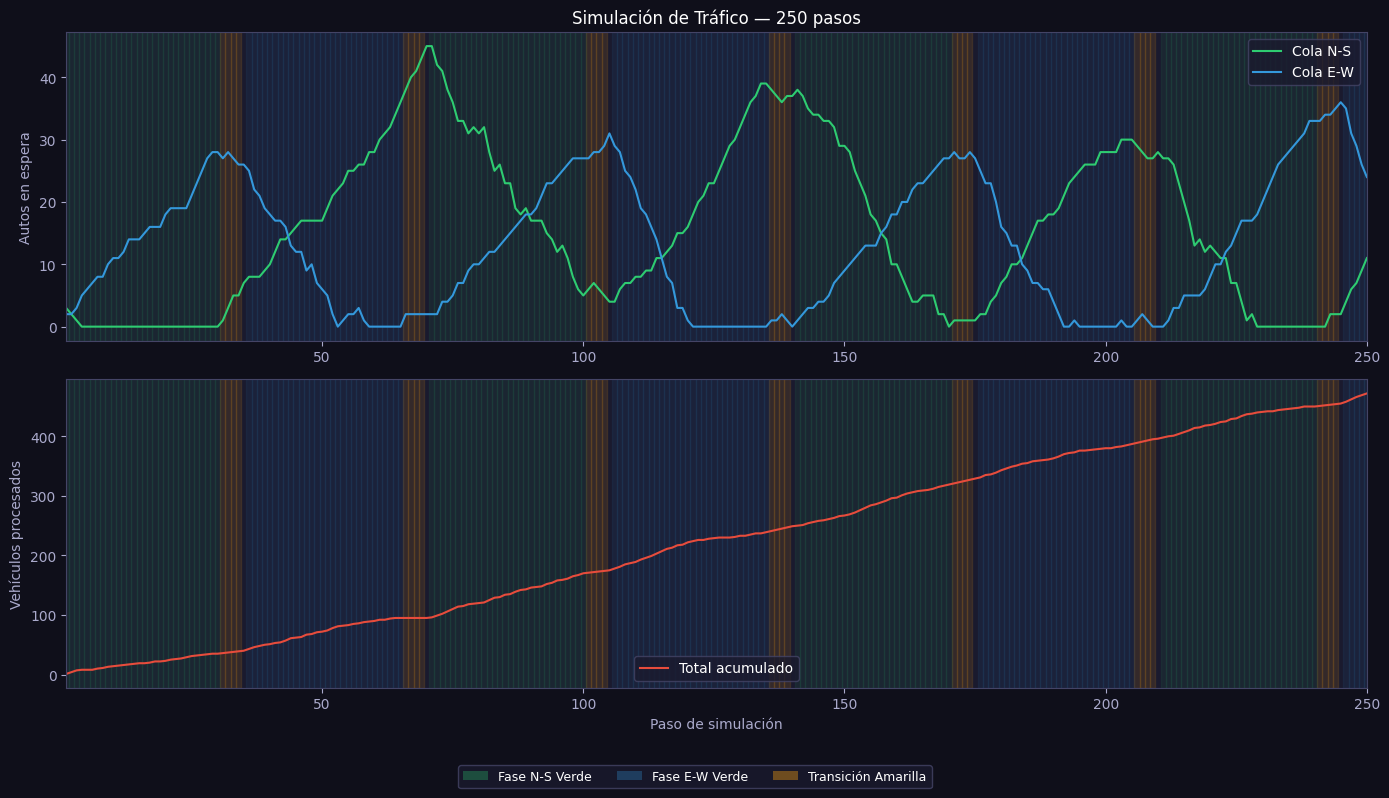

In [12]:
steps = [e["step"] for e in log]
waiting_ns = [e["waiting_ns"] for e in log]
waiting_ew = [e["waiting_ew"] for e in log]
total_pass = [e["total_passed"] for e in log]

# creamos la figura donde se pondrán las gráficas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), facecolor='#0f0f1a')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1a2e')
    ax.spines[:].set_color('#444466')
    ax.tick_params(colors='#aaaacc')

# sombreado de fases
for e in log:
    if e["state_ns"] == "G":
        ax1.axvspan(e["step"]-0.5, e["step"]+0.5, alpha=0.07, color='#2ECC71')
        ax2.axvspan(e["step"]-0.5, e["step"]+0.5, alpha=0.07, color='#2ECC71')
    elif e["state_ew"] == "G":
        ax1.axvspan(e["step"]-0.5, e["step"]+0.5, alpha=0.07, color='#3498DB')
        ax2.axvspan(e["step"]-0.5, e["step"]+0.5, alpha=0.07, color='#3498DB')
    elif e["in_yellow"]:
        ax1.axvspan(e["step"]-0.5, e["step"]+0.5, alpha=0.12, color='#F39C12')
        ax2.axvspan(e["step"]-0.5, e["step"]+0.5, alpha=0.12, color='#F39C12')

ax1.plot(steps, waiting_ns, color='#2ECC71', lw=1.5, label='Cola N-S')
ax1.plot(steps, waiting_ew, color='#3498DB', lw=1.5, label='Cola E-W')
ax1.set_ylabel('Autos en espera', color='#aaaacc')
ax1.set_title('Simulación de Tráfico — 250 pasos', color='white', fontsize=12)
ax1.legend(facecolor='#1a1a2e', labelcolor='white', edgecolor='#444466')
ax1.set_xlim(1, 250)

ax2.plot(steps, total_pass, color='#E74C3C', lw=1.5, label='Total acumulado')
ax2.set_ylabel('Vehículos procesados', color='#aaaacc')
ax2.set_xlabel('Paso de simulación', color='#aaaacc')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', edgecolor='#444466')
ax2.set_xlim(1, 250)

# Leyenda de fases
legend_elements = [
    patches.Patch(facecolor='#2ECC71', alpha=0.3, label='Fase N-S Verde'),
    patches.Patch(facecolor='#3498DB', alpha=0.3, label='Fase E-W Verde'),
    patches.Patch(facecolor='#F39C12', alpha=0.4, label='Transición Amarilla'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           facecolor='#1a1a2e', labelcolor='white', edgecolor='#444466',
           fontsize=9, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('csp_simulacion.png', dpi=150, bbox_inches='tight')
plt.show()

En la gráfica superior, se pueden visualizar los cambios en la cantidad de vehículos que se encuentran en la fila de espera con respecto a los pasos realizados, así como tabién se visualiza dependiendo del color de fondo la fase en la que se encuentran los semáforos. Es notorio cómo la cantidad de vehículos aumenta si la fase opuesta se encuentra en color verde. También, en la transición amarilla se puede notar cómo se llega al pico máximo de vehículos dentro de una de las colas, mientras que en la otra empieza a aumentar. Este comportamiento es periódico y gira en torno a la cantidad de pasos que los semáforos se encuentran en verde y rojo respectivamente.  

En la gráfica inferior, se visualiza el total de vehículos que se procesaron a lo largo de la simulación, logrando un total de 487 automóviles. El crecimiento de vehículos se visualiza aumenta de manera lineal, disminuyendo la tasa de crecimiento ligeramente cuando se encuentra el sistema en la transición amarilla. 

### 3.2 Simulación visual animada

Finalmente, se realizó una simulación visual de manera animada, donde se modifican ligeramente las reglas para permitir la visualización óptima de un flujo de vehículos manejable, a una velocidad decente.  

La simulación numérica logra registrar colas de espera de hasta 40 vehículos y un total de 487 vehículos procesados en total, sin embargo la animación visual no podrá representar estos valores. La animación se enfocará en ilustrar el comportamiento del sistema CSP, incluyendo el ciclo de fases y las restricciones, de manera visualmente amigable así como también estética. Renderizar esa cantidad elevada de vehículos resultará tardada y exhaustiva, además de que podría dificultar observar la lógica del semáforo. Por ello, el mapa limitará las filas de espera en cada dirección a no más de 6 carros.  

Para esta sección, se definen las siguientes funciones: 
- `run_simulation`: replica la lógica de `simulate_traffic` con semilla fija (`random.seed(42)`) para garantizar resultados reproducibles, y genera el log de 250 pasos que consumirá la animación frame por frame.
- `Car`: clase que representa cada vehículo en pantalla. Gestiona su posición, dirección, velocidad, y la lógica de detención ante semáforos y otros vehículos. Incluye el atributo `committed` para implementar la restricción de amarillo: si el vehículo ya superó la línea de parada, continúa avanzando; si no, se detiene.
- `try_spawn`: controla la aparición de nuevos vehículos en el carril, verificando que haya espacio suficiente antes de generar uno nuevo para evitar superposiciones.
- `draw_road`, `draw_traffic_light`, `draw_car`: funciones auxiliares de dibujo que renderizan en cada frame la intersección, los semáforos con sus tres luces y los vehículos con su orientación correcta según la dirección de viaje.
- `animate`: función central de la animación, llamada por `FuncAnimation` en cada frame. Coordina el spawn de vehículos, el movimiento, el redibujado de la escena y la actualización del panel lateral con las métricas del paso actual.

En esta simulación visual se permite ver el comportamiento de los carros con respecto a las luces del semáforo, así como también se permiten interacciones entre los vehículos, detectando si están cerca o no para determinar si seguir avanzando o detenerse. En general, se visualiza un comportamiento muy básico de avanzar a menos que no sea posible. Esto es importante, pues es lo que permite que no haya colisiones entre vehículos. También vale la pena mencionar que la simulación permite entender de mejor manera el comportamiento del semáforo, brindando oportunidad a identificar de manera visual áreas de oportunidad. 

In [13]:
# ============================================================
# SIMULACION VISUAL ANIMADA — 250 pasos con matplotlib
# Amarillo: autos comprometidos siguen; los demas paran.
# ============================================================

random.seed(42)
np.random.seed(42)

TOTAL      = 250
PHASE_DUR  = 30
YELLOW_DUR = 6
CAR_LENGTH = 0.38
MIN_GAP    = 0.75
SAFE_DIST  = CAR_LENGTH + MIN_GAP

def run_simulation():
    log = []
    phase, step_in_phase, in_yellow = 0, 0, False
    wNS, wEW, pNS, pEW = 4, 4, 0, 0
    last_flow_ns, last_flow_ew = 2, 2
    for s in range(1, TOTAL + 1):
        wNS += random.randint(0, 2)
        wEW += random.randint(0, 2)
        if in_yellow:
            stateNS = stateEW = 'Y'
            step_in_phase += 1
            if step_in_phase >= YELLOW_DUR:
                phase = 1 - phase; step_in_phase = 0; in_yellow = False
        else:
            stateNS = 'G' if phase == 0 else 'R'
            stateEW = 'G' if phase == 1 else 'R'
            step_in_phase += 1
            if step_in_phase >= PHASE_DUR:
                in_yellow = True; step_in_phase = 0
        passedNS = passedEW = 0
        if stateNS == 'G':
            passedNS = min(wNS, random.randint(1, 4)); wNS = max(0, wNS - passedNS); pNS += passedNS
            last_flow_ns = passedNS
        elif stateNS == 'Y':
            passedNS = min(wNS, int(round(last_flow_ns * 0.4))); wNS = max(0, wNS - passedNS); pNS += passedNS
        if stateEW == 'G':
            passedEW = min(wEW, random.randint(1, 4)); wEW = max(0, wEW - passedEW); pEW += passedEW
            last_flow_ew = passedEW
        elif stateEW == 'Y':
            passedEW = min(wEW, int(round(last_flow_ew * 0.4))); wEW = max(0, wEW - passedEW); pEW += passedEW
        log.append(dict(step=s, stateNS=stateNS, stateEW=stateEW,
                        wNS=wNS, wEW=wEW, pNS=pNS, pEW=pEW, in_yellow=in_yellow))
    return log

sim = run_simulation()

CAR_COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
              '#1abc9c','#e67e22','#ecf0f1','#ff6b6b','#74b9ff','#fd79a8']

class Car:
    def __init__(self, direction):
        self.direction = direction
        self.color     = random.choice(CAR_COLORS)
        self.speed     = 0.20
        off = 0.38
        if   direction == 'N': self.x =  off; self.y = -6.8
        elif direction == 'S': self.x = -off; self.y =  6.8
        elif direction == 'E': self.x = -6.8; self.y =  off
        elif direction == 'W': self.x =  6.8; self.y = -off
        # Bandera: el carro ya supero la linea de parada
        self.committed = False

    def progress(self):
        if self.direction == 'N': return  self.y
        if self.direction == 'S': return -self.y
        if self.direction == 'E': return  self.x
        if self.direction == 'W': return -self.x

    def stop_line(self):
        return -1.05   # coordenada de progreso de la linea de parada

    def should_stop_light(self, stateNS, stateEW):
        """
        Decide si el semaforo obliga a detenerse.
        Verde    -> nunca para por semaforo.
        Rojo     -> para antes de la linea siempre.
        Amarillo -> para SOLO si aun NO cruzo la linea (committed=False).
                    Si ya cruzo (committed=True), sigue avanzando.
        """
        st = stateNS if self.direction in ('N', 'S') else stateEW

        if st == 'G':
            return False

        prog = self.progress()

        # Actualizar bandera si el carro supero la linea
        if prog >= self.stop_line():
            self.committed = True

        if st == 'Y':
            if self.committed:
                return False   # ya paso la linea: sigue
            return self.stop_line() - SAFE_DIST < prog < self.stop_line()

        # Rojo: siempre para antes de la linea
        return self.stop_line() - SAFE_DIST < prog < self.stop_line()

    def move(self, stateNS, stateEW, all_cars):
        leader_dist      = self._leader_distance(all_cars)
        blocked_by_car   = leader_dist < SAFE_DIST + 0.05
        blocked_by_light = self.should_stop_light(stateNS, stateEW)
        if blocked_by_car or blocked_by_light:
            return
        if   self.direction == 'N': self.y += self.speed
        elif self.direction == 'S': self.y -= self.speed
        elif self.direction == 'E': self.x += self.speed
        elif self.direction == 'W': self.x -= self.speed

    def _leader_distance(self, all_cars):
        min_dist = 1500
        for other in all_cars:
            if other is self: continue
            if other.direction != self.direction: continue
            diff = other.progress() - self.progress()
            if 0 < diff < min_dist:
                min_dist = diff
        return min_dist

    def offscreen(self):
        return abs(self.x) > 7.5 or abs(self.y) > 7.5


cars = []

def try_spawn(direction, all_cars):
    spawn_prog = -6.8
    for c in all_cars:
        if c.direction != direction: continue
        if abs(c.progress() - spawn_prog) < SAFE_DIST * 1.5:
            return
    all_cars.append(Car(direction))

def draw_road(ax):
    ax.set_facecolor('#141b27')
    RW = 1.0
    for (x0, y0, w, h) in [(-6.5,1.0,5.5,5.5),(1.0,1.0,5.5,5.5),
                             (-6.5,-6.5,5.5,5.5),(1.0,-6.5,5.5,5.5)]:
        ax.add_patch(patches.Rectangle((x0,y0), w, h, color='#1a2d1a', zorder=1))
        for xi in np.arange(x0, x0+w, 0.6):
            ax.plot([xi,xi],[y0,y0+h], color='#1e3a1e', lw=0.3, zorder=1)
        for yi in np.arange(y0, y0+h, 0.6):
            ax.plot([x0,x0+w],[yi,yi], color='#1e3a1e', lw=0.3, zorder=1)
    ax.add_patch(patches.Rectangle((-RW,-6.5), RW*2, 13, color='#232c3b', zorder=2))
    ax.add_patch(patches.Rectangle((-6.5,-RW), 13, RW*2, color='#232c3b', zorder=2))
    ax.add_patch(patches.Rectangle((-RW,-RW), RW*2, RW*2, color='#252f40', zorder=3))
    dk = dict(color='#ffe44d', lw=1.2, ls=(0,(4,3)), zorder=4)
    for seg in [([0,0],[-6.5,-RW]),([0,0],[RW,6.5]),([-6.5,-RW],[0,0]),([RW,6.5],[0,0])]:
        ax.plot(seg[0], seg[1], **dk)
    for sign in [-1,1]:
        for seg in [([sign*RW,sign*RW],[-6.5,-RW]),([sign*RW,sign*RW],[RW,6.5]),
                    ([-6.5,-RW],[sign*RW,sign*RW]),([RW,6.5],[sign*RW,sign*RW])]:
            ax.plot(seg[0], seg[1], color='white', alpha=0.18, lw=1, zorder=4)
    sk = dict(color='white', lw=2.5, zorder=5)
    ax.plot([-RW,RW],[-RW,-RW],**sk); ax.plot([-RW,RW],[RW,RW],**sk)
    ax.plot([-RW,-RW],[-RW,RW],**sk); ax.plot([RW,RW],[-RW,RW],**sk)
    zw = 0.16
    for i in range(5):
        for base in [-RW-0.06-(i+0.5)*zw*1.6, RW+0.06+i*zw*1.6]:
            ax.add_patch(patches.Rectangle((-RW+0.05,base), RW*2-0.1, zw,
                                            color='white', alpha=0.14, zorder=4))
            ax.add_patch(patches.Rectangle((base,-RW+0.05), zw, RW*2-0.1,
                                            color='white', alpha=0.14, zorder=4))
    lkw = dict(color='#4a7fa0', fontsize=7, fontfamily='monospace', fontweight='bold', zorder=6)
    ax.text(0, 5.8,'AV. NORTE',   ha='center', va='center', **lkw)
    ax.text(0,-5.8,'AV. SUR',     ha='center', va='center', **lkw)
    ax.text(-5.5,0,'CALLE OESTE', ha='center', va='center', rotation=90,  **lkw)
    ax.text( 5.5,0,'CALLE ESTE',  ha='center', va='center', rotation=-90, **lkw)

def draw_traffic_light(ax, px, py, state):
    ax.plot([px,px],[py,py+0.55], color='#445566', lw=2.5, zorder=8, solid_capstyle='round')
    ax.add_patch(patches.FancyBboxPatch((px-0.18,py+0.55), 0.36, 0.72,
                  boxstyle='round,pad=0.03', fc='#1a2030', ec='#2a3a50', lw=1, zorder=9))
    off_c = {'R':'#4a0a0a','Y':'#4a3a00','G':'#0a2a10'}
    on_c  = {'R':'#ff2222','Y':'#ffcc00','G':'#00ff66'}
    for i, sig in enumerate(['R','Y','G']):
        cy_l = py + 0.55 + 0.58 - i*0.22
        col = on_c[sig] if state == sig else off_c[sig]
        ax.add_patch(plt.Circle((px, cy_l), 0.082, color=col, zorder=10))
        if state == sig:
            ax.add_patch(plt.Circle((px, cy_l), 0.14, color=col, alpha=0.22, zorder=9))

def draw_car(ax, car):
    x, y = car.x, car.y
    angle_r = math.radians({'N':90,'S':-90,'E':0,'W':180}[car.direction])
    L, W2 = CAR_LENGTH, 0.18
    def rot(dx, dy):
        c, s = math.cos(angle_r), math.sin(angle_r)
        return x + dx*c - dy*s, y + dx*s + dy*c
    r2,g2,b2 = (int(car.color.lstrip('#')[i:i+2],16) for i in (0,2,4))
    dark = '#{:02x}{:02x}{:02x}'.format(max(0,r2-45),max(0,g2-45),max(0,b2-45))
    ax.add_patch(plt.Polygon([rot(-L/2,-W2),rot(L/2,-W2),rot(L/2,W2),rot(-L/2,W2)],
                              fc=car.color, ec='black', lw=0.3, zorder=11))
    ax.add_patch(plt.Polygon([rot(-L/2+0.08,-W2+0.04),rot(L/2-0.06,-W2+0.04),
                               rot(L/2-0.06,W2-0.04),rot(-L/2+0.08,W2-0.04)],
                              fc=dark, ec='none', zorder=12))
    ax.add_patch(plt.Polygon([rot(-L/2+0.09,-W2+0.05),rot(-L/2+0.17,-W2+0.05),
                               rot(-L/2+0.17,W2-0.05),rot(-L/2+0.09,W2-0.05)],
                              fc='#a8d8f0', alpha=0.6, ec='none', zorder=13))
    ax.add_patch(plt.Circle(rot( L/2,-W2+0.05), 0.033, color='#ffffaa', zorder=14))
    ax.add_patch(plt.Circle(rot( L/2, W2-0.05), 0.033, color='#ffffaa', zorder=14))
    ax.add_patch(plt.Circle(rot(-L/2,-W2+0.05), 0.028, color='#ff3333', zorder=14))
    ax.add_patch(plt.Circle(rot(-L/2, W2-0.05), 0.028, color='#ff3333', zorder=14))

fig = plt.figure(figsize=(12, 7), facecolor='#0d1117')
gs  = fig.add_gridspec(1, 2, width_ratios=[2.6, 1], wspace=0.08)
ax_scene = fig.add_subplot(gs[0])
ax_panel = fig.add_subplot(gs[1])
for ax in [ax_scene, ax_panel]:
    ax.axis('off')
ax_scene.set_xlim(-6.5, 6.5); ax_scene.set_ylim(-6.5, 6.5)
ax_scene.set_aspect('equal'); ax_scene.set_facecolor('#141b27')

hist_pNS, hist_pEW = [], []

def animate(frame_idx):
    global cars
    entry = sim[frame_idx]
    stateNS, stateEW = entry['stateNS'], entry['stateEW']

    if stateNS == 'G':
        if random.random() < 0.36: try_spawn('N', cars)
        if random.random() < 0.36: try_spawn('S', cars)
    if stateEW == 'G':
        if random.random() < 0.36: try_spawn('E', cars)
        if random.random() < 0.36: try_spawn('W', cars)
    if random.random() < 0.10:
        try_spawn(random.choice(['N','S','E','W']), cars)

    cars_sorted = sorted(cars, key=lambda c: -c.progress())
    for car in cars_sorted:
        car.move(stateNS, stateEW, cars)
    cars = [c for c in cars if not c.offscreen()]

    ax_scene.cla()
    ax_scene.set_xlim(-6.5, 6.5); ax_scene.set_ylim(-6.5, 6.5)
    ax_scene.set_aspect('equal'); ax_scene.axis('off')
    ax_scene.set_facecolor('#141b27')
    draw_road(ax_scene)

    if stateNS == 'G':
        ax_scene.add_patch(patches.Rectangle((-1.0,-6.5),2.0,13,color='#00ff66',alpha=0.03,zorder=2))
    elif stateNS == 'Y':
        ax_scene.add_patch(patches.Rectangle((-1.0,-6.5),2.0,13,color='#ffcc00',alpha=0.04,zorder=2))
    if stateEW == 'G':
        ax_scene.add_patch(patches.Rectangle((-6.5,-1.0),13,2.0,color='#0066ff',alpha=0.03,zorder=2))
    elif stateEW == 'Y':
        ax_scene.add_patch(patches.Rectangle((-6.5,-1.0),13,2.0,color='#ffcc00',alpha=0.04,zorder=2))

    for car in cars:
        draw_car(ax_scene, car)

    draw_traffic_light(ax_scene, -1.22, -1.82, stateNS)
    draw_traffic_light(ax_scene,  1.22, -1.82, stateEW)
    draw_traffic_light(ax_scene, -1.22,  1.08, stateNS)
    draw_traffic_light(ax_scene,  1.22,  1.08, stateEW)

    cx2, cy2 = -5.5, 5.5
    ax_scene.add_patch(plt.Circle((cx2,cy2),0.55,fc='#0d1520',ec='#2a4a6a',lw=1.2,zorder=20))
    for txt,dx,dy in [('N',0,.34),('S',0,-.34),('E',.34,0),('W',-.34,0)]:
        ax_scene.text(cx2+dx,cy2+dy,txt,ha='center',va='center',fontsize=6,
                      color='#aaccee',fontfamily='monospace',fontweight='bold',zorder=21)
    ax_scene.plot([cx2,cx2],[cy2,cy2+.24],color='#ff4444',lw=1.5,zorder=21)
    ax_scene.plot([cx2,cx2],[cy2,cy2-.24],color='#888888',lw=1.5,zorder=21)

    ax_scene.text(-6.2, 6.0, f'STEP  {entry["step"]:03d} / {TOTAL}',
                  fontsize=9, color='#66ddff', fontfamily='monospace', fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.3',fc='#0a1520',ec='#2a4a6a'), zorder=30)

    if entry['in_yellow']:
        ptxt, pcol = '** TRANSICION AMARILLA **', '#ffcc00'
    elif stateNS == 'G':
        ptxt, pcol = '[VERDE] FASE 1  NORTE - SUR', '#00ff66'
    else:
        ptxt, pcol = '[VERDE] FASE 2  ESTE - OESTE', '#00aaff'
    ax_scene.text(0.5, 6.0, ptxt, ha='center', fontsize=7.5, color=pcol,
                  fontfamily='monospace', fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.3',fc='#0a1520',ec='#2a4a6a'), zorder=30)
    ax_scene.text(0,-6.2,'CSP - Control de Intersecciones con Restricciones',
                  ha='center',fontsize=7,color='#446688',fontfamily='monospace',zorder=30)

    ax_panel.cla(); ax_panel.axis('off')
    ax_panel.set_facecolor('#0a1220')
    ax_panel.set_xlim(0,1); ax_panel.set_ylim(0,1)
    def pt(x, y, txt, **kw):
        ax_panel.text(x, y, txt, transform=ax_panel.transAxes, **kw)

    pt(0.5,0.96,'SIMULACION CSP',ha='center',fontsize=10,
       color='#66ddff',fontfamily='monospace',fontweight='bold')
    pt(0.5,0.90,'- '*14,ha='center',fontsize=7,color='#2a4a6a')
    pt(0.08,0.86,'SEMAFOROS',fontsize=8,color='#66ddff',
       fontfamily='monospace',fontweight='bold')
    dot_c   = {'G':'#00ff66','Y':'#ffcc00','R':'#ff2222'}
    st_name = {'G':'VERDE','Y':'AMARILLO','R':'ROJO'}
    for i,(lbl,st) in enumerate([('NORTE',stateNS),('SUR',stateNS),
                                  ('ESTE',stateEW),('OESTE',stateEW)]):
        y_pos = 0.80 - i*0.065
        ax_panel.add_patch(plt.Circle((0.10,y_pos+0.018),0.042,
                            color=dot_c[st],transform=ax_panel.transAxes,zorder=5))
        pt(0.22,y_pos,lbl,          fontsize=8,color='#aaaacc',fontfamily='monospace')
        pt(0.60,y_pos,f'[{st_name[st]}]',fontsize=7.5,
           color=dot_c[st],fontfamily='monospace',fontweight='bold')

    pt(0.5,0.55,'- '*14,ha='center',fontsize=7,color='#2a4a6a')
    pt(0.08,0.51,'TRAFICO',fontsize=8,color='#66ddff',
       fontfamily='monospace',fontweight='bold')
    pt(0.08,0.45,f'Cola N-S :  {entry["wNS"]:>3}',fontsize=8,
       color='#2ecc71',fontfamily='monospace')
    pt(0.08,0.39,f'Cola E-W :  {entry["wEW"]:>3}',fontsize=8,
       color='#3498db',fontfamily='monospace')
    pt(0.08,0.33,f'Pass. N-S:  {entry["pNS"]:>3}',fontsize=8,
       color='#88ee99',fontfamily='monospace')
    pt(0.08,0.27,f'Pass. E-W:  {entry["pEW"]:>3}',fontsize=8,
       color='#88bbff',fontfamily='monospace')
    pt(0.08,0.21,f'TOTAL   :  {entry["pNS"]+entry["pEW"]:>3}',fontsize=8,
       color='#ffffaa',fontfamily='monospace',fontweight='bold')

    pt(0.5,0.15,'- '*14,ha='center',fontsize=7,color='#2a4a6a')
    prog = entry['step'] / TOTAL
    ax_panel.add_patch(patches.Rectangle((0.05,0.08),0.90,0.042,
                        fc='#1a2a3a',ec='#2a4a6a',lw=1,transform=ax_panel.transAxes,zorder=4))
    ax_panel.add_patch(patches.Rectangle((0.05,0.08),0.90*prog,0.042,
                        fc='#1a6aff',transform=ax_panel.transAxes,zorder=5))
    pt(0.5,0.04,f'{entry["step"]} / {TOTAL}',ha='center',fontsize=8,
       color='#6699aa',fontfamily='monospace')

    hist_pNS.append(entry['pNS'])
    hist_pEW.append(entry['pEW'])
    if len(hist_pNS) > 1:
        mx = max(max(hist_pNS), max(hist_pEW), 1)
        xs = [0.05 + 0.90*(t/TOTAL) for t in range(len(hist_pNS))]
        ax_panel.plot(xs,[0.60+0.12*(v/mx) for v in hist_pNS],
                      color='#2ecc71',lw=0.9,transform=ax_panel.transAxes,zorder=6)
        ax_panel.plot(xs,[0.60+0.12*(v/mx) for v in hist_pEW],
                      color='#3498db',lw=0.9,transform=ax_panel.transAxes,zorder=6)
    pt(0.5,0.74,'Vehiculos acumulados',ha='center',fontsize=6.5,
       color='#446688',fontfamily='monospace')

anim = FuncAnimation(fig, animate, frames=TOTAL, interval=120, repeat=False)
plt.tight_layout(pad=0.4)
plt.close()
HTML(anim.to_jshtml())

Writer = animation.FFMpegWriter(fps=10, bitrate=1800)
anim.save('CSP_Traffic_Simulacion.mp4', writer=Writer, dpi=120)


c:\progra\Python\TC2032\.venv\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
C:\Users\Laurie Hernández\AppData\Local\Temp\ipykernel_1456\3142720584.py:345: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.4)


## 4. Análisis 

Se definieron **4 variables** representando el estado del semáforo en cada dirección cardinal: `L_N` (Norte), `L_S` (Sur), `L_E` (Este) y `L_W` (Oeste). Cada una puede tomar valores del dominio `{R, Y, G}` (Rojo, Amarillo o Verde).

Se aplicaron cinco restricciones fundamentales:
- **Compatibilidad Norte-Sur:** Pueden estar verdes simultáneamente los flujos Norte y Sur
- **Compatibilidad Este-Oeste:** Pueden estar verdes simulaneamente los flujos Este y Oeste
- **Anti-colisión cruzada:** Los flujos Norte-Sur y Este-Oeste **no pueden estar en verde simultáneamente**, ya que generarían conflictos físicos en la intersección.
- **Actividad mínima:** Al menos una dirección debe tener verde, evitando bloqueos totales innecesarios.
- **Transición en amarillo**: Los flujos al cambiar de color utilizan una transición en amarillo que permite frenar a los vehículos que todavía no se encuentran en la intersección, mientras que permite avanzar a aquellos que ya se encuentran a más allá de la línea de distancia. 


El algoritmo de backtracking encontró **4 configuraciones válidas** (de $3^4$ posibles). Estas configuraciones se agrupan en tres familias:
- Flujo **Norte-Sur** activo
- Flujo **Este-Oeste** activo
- Flujo **Norte-Sur** en transición
- Flujo **Este-Oeste** en transición

Las principales diferencias entre CSP, heurísticas o aprendizaje por refuerzo como Q-learning gira en torno a las limitaciones del sistema y también el uso de cada estrategia depende del problema que se esté tratando.  
Una heurística predefine reglas fijas y explícitas, suelen tener bajo costo y pueden ser escalables hasta cierto punto, si la heurística no es admisible, puede no ser tan completa ni óptima. Mientras tanto, Q-Learning logra converger con suficiente entrenamiento, así como también es adaptable con base en la cantidad de casos de entrenamiento que se le otorga. Además, logra escalar bien con múltiples cruces, que en este caso no es la situación. Sin embargo, puede requerir muchas iteraciones hasta que logre converger, así como también tiene baja interpretabilidad. Finalmente, a través de CSP se garantiza encontrar todas las soluciones válidas a través de combinatoria, además de que es muy claro y se puede verificar, pues se cuenta con las reglas de descripción. Es simple para problemas que no son tan grandes, sin embargo el uso de combinatoria limita su escalabilidad pues crece de una manera descontrolada. Además, es poco adaptable, pues no aprende del tráfico y se tienen restricciones y apredefinidas.  

Para este cruce en específico, el enfoque CSP es ideal pues permite validar restricciones de seguridad y garantizar que no existirán colisiones en las posibles configuraciones encontradas. Sin embargo, en caso de querer escalar este problema con múltiples intersecciones o tráfico variable, valdría la pena explorar otras opciones como Q-Learning y su implementación. 